<a href="https://colab.research.google.com/github/uiuxkelompok/uts-bigdata/blob/main/Google_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.supercell.clashofclans',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=100,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 100 ulasan ke 'ulasan_google_play.csv'


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
pip install transformers

In [10]:
import pandas as pd
from transformers import pipeline

# Convert the list of dictionaries to a pandas DataFrame
df = pd.DataFrame(result)

# Initialize the sentiment analysis pipeline with the specified model
sentiment_analyzer = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-prdect-id")

# Perform sentiment analysis on the 'content' column
df['sentiment'] = df['content'].apply(lambda x: sentiment_analyzer(x)[0]['label'])
df['sentiment_score'] = df['content'].apply(lambda x: sentiment_analyzer(x)[0]['score'])

# Display the DataFrame with sentiment analysis results
display(df[['content', 'sentiment', 'sentiment_score']].head())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-prdect-id
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,content,sentiment,sentiment_score
0,"server legg, terus kebanyakan update",Sadness,0.387641
1,"menyerang gagal terus, kesalahan atau",Fear,0.473098
2,selalu trjadi kesalahan saat memulai penyerang...,Fear,0.648065
3,kalau bisa adakan Network Boost seperti mobile...,Fear,0.673494
4,Disconnect Disconnect Disconnect sering banget...,Fear,0.598408


/tmp/ipykernel_1561/3478066367.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, ax=axes[0], palette='viridis')


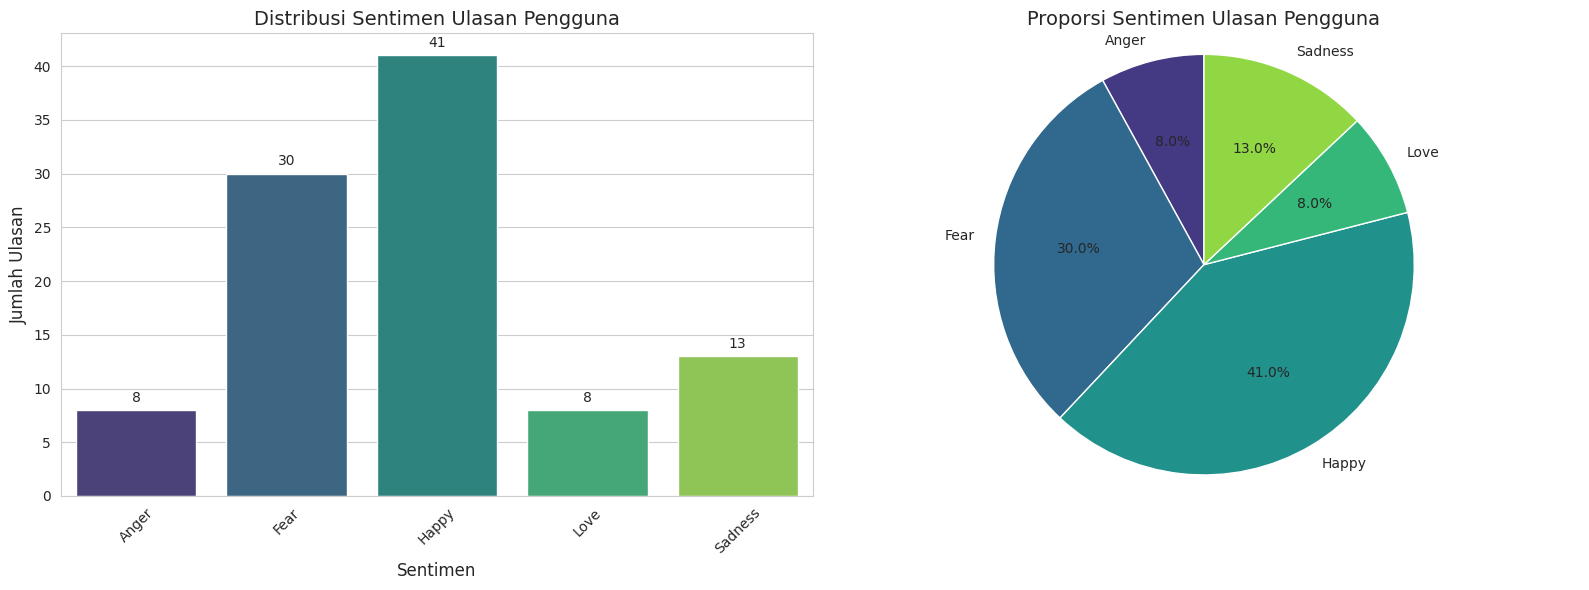

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Bar Chart of Sentiment Distribution
sentiment_counts = df['sentiment'].value_counts().sort_index()
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Sentimen Ulasan Pengguna', fontsize=14)
axes[0].set_xlabel('Sentimen', fontsize=12)
axes[0].set_ylabel('Jumlah Ulasan', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Add count labels on top of the bars
for index, value in enumerate(sentiment_counts.values):
    axes[0].text(index, value + 0.5, str(value), ha='center', va='bottom')

# Subplot 2: Pie Chart of Sentiment Proportion
colors = sns.color_palette('viridis', len(sentiment_counts))
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Proporsi Sentimen Ulasan Pengguna', fontsize=14)
axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()